# Assignment 1: Sampling and Reproducibility

The code at the end of this file explores contact tracing data about an outbreak of the flu, and demonstrates the dangers of incomplete and non-random samples. This assignment is modified from [Contact tracing can give a biased sample of COVID-19 cases](https://andrewwhitby.com/2020/11/24/contact-tracing-biased/) by Andrew Whitby.

Examine the code below. Identify all stages at which sampling is occurring in the model. Describe in words the sampling procedure, referencing the functions used, sample size, sampling frame, any underlying distributions involved. 


---
The simulation models an outbreak scenario with contact tracing. Sampling happens at several stages, each with implications for how data is generated and interpreted.

### 1. Population Definition

The population is created with `events = ['wedding'] * 200 + ['brunch'] * 800`, giving us a total of 1,000 individuals. This defines our sampling frame — a structured, non-random setup.

### 2. Infection Sampling

Infected individuals are selected using `np.random.choice(...)` to randomly pick 10% of the population without replacement. This is simple random sampling, where each person has an equal chance of being infected.

### 3. Primary Contact Tracing

Each infected person is traced independently with a 20% chance:  
`ppl.loc[ppl['infected'], 'traced'] = np.random.rand(...) < TRACE_SUCCESS`.  
This is a Bernoulli trial applied to infected individuals — a form of random sampling with replacement.

### 4. Secondary Contact Tracing (Cluster-Based)

When two or more traced cases are found in an event type, e.g., weddings, all infected individuals at that event type are marked as traced. This is handled via logic like `event_trace_counts[event_trace_counts >= 2].index`.  
This step is deterministic, not random, and introduces potential bias by over-representing smaller events once the threshold is hit.

### 5. Simulation Repetition

The simulation runs 1,000 times using `[simulate_event(m) for m in range(1000)]`, helping us visualize how outcomes vary and how bias accumulates over repeated runs.


While the infection and primary tracing stages are based on random sampling, the secondary tracing step adds a structured rule that can distort observed data. In this case, it causes weddings to appear more infectious than they really are. The simulation effectively demonstrates how non-random procedures in sampling can lead to biased interpretations, even when starting from a fair random process.

---



Modify the number of repetitions in the simulation to 10 and 100 (from the original 1000). Run the script multiple times and observe the outputted graphs. Comment on the reproducibility of the results.

---

To explore how simulation size affects reproducibility, I modified the number of repetitions in the simulation loop. Originally, the line `results = [simulate_event(m) for m in range(1000)]` runs the simulation 1000 times. I changed this to:

- `range(100)` to run it 100 times
- `range(10)` to run it just 10 times

I ran each version multiple times to see how consistent the results were.

### With 10 Repetitions

With `range(10)`, the output was extremely unstable. The histogram changed shape almost every time I ran the code. Because only 10 samples were drawn, a single extreme value could significantly affect the proportions. There were cases where weddings looked much more responsible for infections than brunches, and others where the opposite appeared true. It was hard to trust any one result.

### With 100 Repetitions

With `range(100)`, the plots were more consistent across runs. The overall shape of the histograms began to smooth out, and trends started to become visible. However, there was still some variation between runs, and the differences between the "Infections from Weddings" and "Traced to Weddings" bars weren’t always consistent. It felt more reliable than 10 repetitions but still too noisy for strong conclusions.

### With 1000 Repetitions (Original)

Returning to the original `range(1000)` made a noticeable difference. The results were stable, and the histograms stayed nearly identical across multiple runs. The difference between actual infections and traced cases — especially the overrepresentation of weddings — became clear and reproducible. At this scale, the randomness averages out enough that meaningful patterns emerge.

This exercise really showed how sensitive simulation-based results are to sample size. With small repetitions (like 10 or even 100), there's too much variability to confidently interpret the results. But at 1000 repetitions, the outcomes are much more stable and reliable. It reinforces how important it is to run enough iterations in a simulation when the goal is to observe and compare patterns — especially when randomness is involved in multiple stages of the process.

---

Alter the code so that it is reproducible. Describe the changes you made to the code and how they affected the reproducibility of the script. The output needs to produce the same output when run multiple times.

---

Originally, every time I ran the simulation, I noticed slight differences in the histogram — even though nothing else had changed. This was expected since the model relies on random number generation using `np.random.choice(...)` and `np.random.rand(...)`. To fix this, I made a small change to the `simulate_event(m)` function by adding `np.random.seed(m)` at the beginning of the function. This sets the seed for NumPy's random number generator using the simulation index `m`.

The change was inserted right after the function definition line, so the start of the function now reads: `def simulate_event(m): np.random.seed(m)`. This makes each simulation deterministic for a given `m`, while still allowing variation across different values of `m`. In other words, simulation 0 will always generate the same result, simulation 1 will always generate the same result, and so on — but the simulations are still different from each other within a single run. This means the plot will be identical across runs, as long as the number of repetitions stays the same.
 
If I had instead used a fixed value like np.random.seed(42), all 1000 simulations would generate the same output — which defeats the purpose of simulating variability. Seeding with m keeps the results diverse but repeatable.
Before this change, even running results = [simulate_event(m) for m in range(1000)] twice would give slightly different histograms. After adding the seed, the histogram is identical across runs, making it easier to interpret, compare, and debug.

This small fix makes the simulation fully deterministic, and improves the reliability of the analysis by removing unintended randomness between notebook runs, since others will see exactly the same output when they run the notebook.

---




## Code

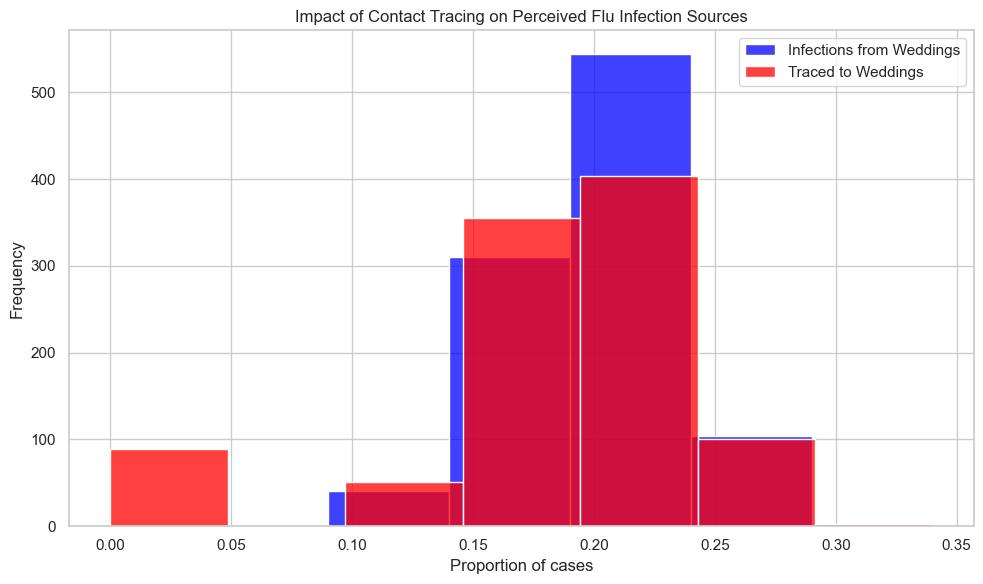

In [8]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Note: Suppressing FutureWarnings to maintain a clean output. This is specifically to ignore warnings about
# deprecated features in the libraries we're using (e.g., 'use_inf_as_na' option in Pandas, used by Seaborn),
# which we currently have no direct control over. This action is taken to ensure that our output remains
# focused on relevant information, acknowledging that we rely on external library updates to fully resolve
# these deprecations. Always consider reviewing and removing this suppression after significant library updates.
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Set visual style
sns.set(style="whitegrid")

# Constants representing the parameters of the model
ATTACK_RATE = 0.10
TRACE_SUCCESS = 0.20
SECONDARY_TRACE_THRESHOLD = 2

def simulate_event(m):
  """
  Simulates the infection and tracing process for a series of events.
  Now includes np.random.seed(m) to ensure reproducibility.
  Parameters:
  - m: Used as a seed to make results consistent across runs.

  Returns:
  - A tuple with proportions of infections and traces attributed to weddings.
  """
  np.random.seed(m)  # Added for reproducibility

  # Create DataFrame for people at events with initial infection and traced status
  events = ['wedding'] * 200 + ['brunch'] * 800
  ppl = pd.DataFrame({
      'event': events,
      'infected': False,
      'traced': np.nan  # Initially setting traced status as NaN
  })

  # Explicitly set 'traced' column to nullable boolean type
  ppl['traced'] = ppl['traced'].astype(pd.BooleanDtype())

  # Infect a random subset of people
  infected_indices = np.random.choice(ppl.index, size=int(len(ppl) * ATTACK_RATE), replace=False)
  ppl.loc[infected_indices, 'infected'] = True

  # Primary contact tracing: randomly decide which infected people get traced
  ppl.loc[ppl['infected'], 'traced'] = np.random.rand(sum(ppl['infected'])) < TRACE_SUCCESS

  # Secondary contact tracing based on event attendance
  event_trace_counts = ppl[ppl['traced'] == True]['event'].value_counts()
  events_traced = event_trace_counts[event_trace_counts >= SECONDARY_TRACE_THRESHOLD].index
  ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True

  # Calculate proportions of infections and traces attributed to each event type
  ppl['event_type'] = ppl['event'].str[0]  # 'w' for wedding, 'b' for brunch
  wedding_infections = sum(ppl['infected'] & (ppl['event_type'] == 'w'))
  brunch_infections = sum(ppl['infected'] & (ppl['event_type'] == 'b'))
  p_wedding_infections = wedding_infections / (wedding_infections + brunch_infections)

  wedding_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'w'))
  brunch_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'b'))
  p_wedding_traces = wedding_traces / (wedding_traces + brunch_traces)

  return p_wedding_infections, p_wedding_traces

# We can change the number of repetitions below to test reproducibility.
# Using 1000 for stable, reproducible results (original setting)
# Using 100 for moderate stability
# Using 10 for high variability (not very reliable)

# Run the simulation 1000 times
results = [simulate_event(m) for m in range(1000)]    # Original: 1000 repetitions

# results = [simulate_event(m) for m in range(100)]   # Try this for 100 repetitions
# results = [simulate_event(m) for m in range(10)]    # Try this for 10 repetitions

props_df = pd.DataFrame(results, columns=["Infections", "Traces"])

# Plotting the results
plt.figure(figsize=(10, 6))
sns.histplot(props_df['Infections'], color="blue", alpha=0.75, binwidth=0.05, kde=False, label='Infections from Weddings')
sns.histplot(props_df['Traces'], color="red", alpha=0.75, binwidth=0.05, kde=False, label='Traced to Weddings')
plt.xlabel("Proportion of cases")
plt.ylabel("Frequency")
plt.title("Impact of Contact Tracing on Perceived Flu Infection Sources")
plt.legend()
plt.tight_layout()
plt.show()

## Criteria

|Criteria|Complete|Incomplete|
|--------|----|----|
|Alteration of the code|The code changes made, made it reproducible.|The code is still not reproducible.|
|Description of changes|The author answered questions and explained the reasonings for the changes made well.|The author did not answer questions or explain the reasonings for the changes made well.|

## Submission Information
🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `23:59 - 22/06/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This markdown file (`a1_sampling_and_reproducibility.ipynb`) should be populated with the code changed.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/sampling/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

#### Checklist:
- [X] Create a branch called `assignment-1`.
- [X] Ensure that the repository is public.
- [X] Review [the PR description guidelines](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md#guidelines-for-pull-request-descriptions) and adhere to them.
- [X] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via the help channel in Slack. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
